In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import math

# from pyfmreaderpsnex.ps_nex.loadMaps import checkMapFileNULL, remove_nan_and_get_indices, load_map_file_csv, compute_time_difference
# from pyfmreaderpsnex.ps_nex.parseTDMS import get_channel_names, parse_tdms, grab_tdms
# from pyfmreaderpsnex.plotting import smooth_derivative
from pyfmreader import loadfile

import plotly.graph_objects as go
import plotly.io as pio

import pandas as pd
import seaborn as sns

pi = math.pi
from pyfmreader.ps_nex.parseTDMS import grab_tdms, parse_tdms

# Add scripts to path
scripts_dir = os.path.abspath('../scripts')
if scripts_dir not in sys.path:
    
    sys.path.insert(0, scripts_dir)


import tether_script as tether


# from pyfmrheo.utils.force_curves import get_poc_RoV_method, get_poc_regulaFalsi_method, correct_tilt, correct_offset
 

In [2]:
filename = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/03/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.31.15.19.tdms'
directory = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/300/'

first_file, all_files = grab_tdms(directory)

print(f'number of tdms files found: {len(all_files)}')

number of tdms files found: 48


In [3]:

# Define parameters
params = {
    'sav_window_length': 10,
    'sav_polyorder': 1,
    'pl_threshold': 150e-9,
    'pl_min_width': 2,
    'last_num_plateaus': 7,
}

# # Use the function
# results = process_single_file(first_file, params)

# print(f"Found {len(plateaus)} plateaus")
# print(df_plat)

In [4]:
# Load file
try: 
    file = loadfile(filename, hs3_bool=False)
except Exception as e:
    print (f'Error: {e}')
    print(" Could not load file, will try hs3 format...")
    file = loadfile(filename, hs3_bool=True)
    # return None

# Get file metadata
filemetadata = file.filemetadata
height_channel_key = filemetadata['height_channel_key']

# Check if custom calibration is enabled
use_custom_calibration = params.get('use_custom_calibration', False)

if use_custom_calibration:
    # Use custom calibration values from parameters
    K = params.get('spring_const_Nbym', 0.05)  # N/m
    file_deflection_sensitivity = params.get('defl_sens_nmbyV', 50.0)  # nm/V
    defl_sens = file_deflection_sensitivity / 1e9  # m/V
else:
    # Use calibration values from file metadata
    file_deflection_sensitivity = filemetadata['defl_sens_nmbyV']  # nm/V
    K = filemetadata['spring_const_Nbym']  # N/m
    defl_sens = file_deflection_sensitivity / 1e9  # m/V

# Get force curve with parameters from GUI
# z_sensor_delay = params.get('z_sensor_delay', 0.001)
# bool_correct_overshoot = params.get('bool_correct_overshoot', True)
force_curve = file.getcurve(0)
force_curve.preprocess_force_curve(defl_sens, height_channel_key)

# Get segments
# segs = force_curve.get_segments()
# final_nb_points = filemetadata['final_nb_points']
relative_SR = filemetadata['relative_sr']

# Extract retract segment data
for segid, segment in force_curve.get_segments():
    if segment.segment_type in ('Approach', 'App'):
        pass  # We only need retract data for this analysis
    elif segment.segment_type in ('Retract', 'Ret'):
        ret_piezo = -segment.zheight
        ret_deflection = -segment.vdeflection * K
        relative_SR_ret = relative_SR[segid]
        vel_ret_um_s = segment.velocity * 1e06  # Convert from nm to um/s
        time_ret = np.arange(len(ret_piezo)) * relative_SR_ret 


print (f'relative_Sr: {relative_SR_ret}, velocity in um/s: {vel_ret_um_s}')

relative_Sr: 0.002, velocity in um/s: 2.9965304999999995


In [5]:
# Tilt correction
max_offset = params.get('max_offset', 100)  # %
min_offset = params.get('min_offset', 70)   # %
max_offset, min_offset = tether.update_tilt_range(ret_piezo, max_offset, min_offset, offset_type='percentage')
tilt_ret_deflection_N = tether.correct_tilt(ret_piezo, ret_deflection, max_offset, min_offset)

# ADD Denoise processing here
filtered_signal = tilt_ret_deflection_N.copy()
fourier_data = {}  # Initialize Fourier data storage

# # Apply denoising if enabled
# if params.get('enable_denoising', False):
#     try:
#         # Get denoising parameters
#         w0 = params.get('denoise_w0', 0.1)
#         w1 = params.get('denoise_w1', 1.0)
#         butterworth_order = params.get('butterworth_order', 5)
#         remove_percent = params.get('denoise_remove_percent', 10)
#         remove_end_percent = params.get('denoise_remove_end_percent', 10)
#         use_interpolation = params.get('denoise_interp', True)
#         w_min = params.get('denoise_w_min', 1.0)
#         w_max = params.get('denoise_w_max', 6.0)
        
#         # Calculate remove indices for both start and end
#         remove_start_index = remove_percent * len(ret_piezo) // 100
#         remove_end_index = remove_end_percent * len(ret_piezo) // 100
#         end_index = len(ret_piezo) - remove_end_index
        
#         # Prepare signal for filtering (remove both start and end portions)
#         from scipy.signal import detrend
#         signal_trimmed = detrend(tilt_ret_deflection_N[remove_start_index:end_index])
        
#         # Calculate parameters for FFT
#         sampling_rate = 1 / relative_SR_ret

In [ ]:
velocity_calc = -tether.calculate_velocity(ret_piezo, time_ret)  # µm/s
# Use filtered signal for further processing
tilt_ret_deflection_N = filtered_signal

# Find contact point 
index_first_positive = tether.find_first_positive(tilt_ret_deflection_N)
first_positive_displacement = ret_piezo[index_first_positive]
ret_corrected_displacement = ret_piezo - first_positive_displacement

# Apply Savitzky-Golay smoothing in force curve
savitz_defl = tether.savitzky_golay_smooth(tilt_ret_deflection_N, window_length=5, polyorder=1)

# Extract data after contact point
defl_savitz = savitz_defl[index_first_positive:]
displacement = ret_corrected_displacement[index_first_positive:]
rel_time = np.arange(len(displacement)) * relative_SR_ret



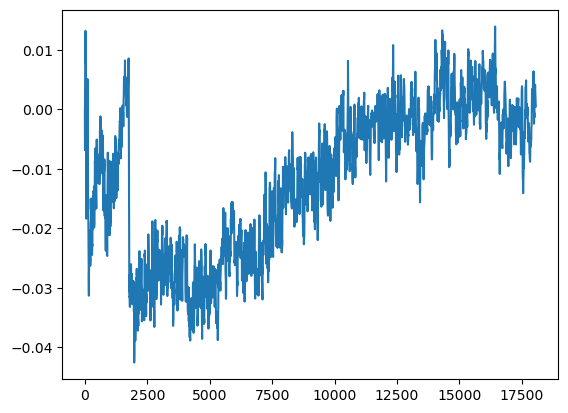

In [7]:
plt.plot(displacement*1e9, defl_savitz*1e9)

In [8]:
    # add case structure to choose what method used for analysis
# Find plateaus
plateaus, df_plat, df_data, velocity_calc_um_s = tether.find_plateaus(displacement, defl_savitz, params, dt=relative_SR_ret)

Using full arrays for plateau detection. Length: 2850
Raw plateaus found: 1


TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'